In [8]:
import pandas as pd
import numpy as np
from scipy.stats import *
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats import weightstats, proportion 

from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import tt_ind_solve_power

In [2]:
df = pd.read_csv('../data/raw/data.csv', parse_dates=['date'])
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               126 non-null    datetime64[ns]
 1   publisher_id       126 non-null    int64         
 2   platform           126 non-null    object        
 3   group_name         126 non-null    object        
 4   pageviews          126 non-null    int64         
 5   visible_pageviews  126 non-null    int64         
 6   sessions           126 non-null    int64         
 7   revenue            126 non-null    float64       
 8   sponsord_clicks    126 non-null    int64         
 9   organic_clicks     126 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(2)
memory usage: 10.0+ KB


,date,publisher_id,platform,group_name,pageviews,visible_pageviews,sessions,revenue,sponsord_clicks,organic_clicks
0,2019-03-01,101,Desktop,A,16580,5418,12684,34.5201,300,849
1,2019-03-01,101,Desktop,B,16191,4906,12717,32.9211,268,555
2,2019-03-01,106,Desktop,A,16227,11395,11750,20.1620,601,2425


Проверка валидности данных:
- соблюдения пропорции по группам (50/50)
- достаточное количество наблюдений для проведения анализа АВ-теста

В связи с тем, что 3 издательства представлены только на mobile-платформе, 4 издательства только на desktop-платформе, 1 на обеих, дальнейший анализ будем проводить отдельно для каждой страты:
 - отдельно Desktop-издательства
 - отдельно Mobile-издательства


In [4]:
# соблюдение пропорции в выборке
alpha = 0.05
MDE = 0.05
# Н0: пропорции соблюдены, выборки представлены пропорционально 50/50
# Н1: пропорции нарушены
platforms = df['platform'].unique()
for name in platforms:
    print(name)
    df_platform = df[df['platform'] == name]
    amount_dict = df_platform.groupby('group_name')['sessions'].sum().to_dict()
    #print(amount_dict)
    observed = [amount_dict['A'], amount_dict['B']]
    expected = [sum(observed)/2, sum(observed)/2]
    chi_pvalue = chisquare(observed, f_exp=expected).pvalue
    if chi_pvalue < alpha:
        print(f'''
Тест показал, что текущее значение pvalue = {chi_pvalue} меньше минимального уровня значимости.
Это дает основание отвергнуть нулевую гипотезу о равенстве пропорций в выборке в пользу альтернативной.
{amount_dict} Дисбаланс: {round((amount_dict['B'] - amount_dict['A'])/amount_dict['B']*100,1)}%.
Текущие данные не являются репрезентабельными! 
Необходимо проверить данные на наличие ошибок и выбросов (дисбаланс по дням, платформам, издателям)
            ''')
    stat, p_value = proportion.proportions_ztest(observed, [sum(observed),sum(observed)])
    p_value

    # pvalue = 0 < alpha, а это означает, что данные не могут считаться репрезентабельными
    # попробуем избавиться от шума

    # Поиск расхождения данных по дням. 
    df_daily = df_platform.groupby(['date', 'group_name'])['sessions'].sum().unstack()
    df_daily['pvalue'] = df_daily.apply(lambda row: chisquare([row['A'],row['B'] ], f_exp = [(row['A']+row['B'])/2,(row['A']+row['B'])/2])[1], axis=1)
    ratio_r = [] # вычисление веса В от тотал наблюдений за день
    for ind, row in df_daily.iterrows():
        ratio_r.append(row['B']/(row['A'] + row['B']))
    df_daily['ratio'] = ratio_r
    df_daily['delta %'] = (0.5 - df_daily['ratio']) * 100
    df_err = df_daily.query('pvalue < 0.05')
    if len(df_err):
        print(f'Найдены дни с некорректными данными. Необходимо принять решение по дальнейшим действиям')
        print(f'''{df_err}
              ''')

Desktop

Тест показал, что текущее значение pvalue = 0.0 меньше минимального уровня значимости.
Это дает основание отвергнуть нулевую гипотезу о равенстве пропорций в выборке в пользу альтернативной.
{'A': 367433, 'B': 401552} Дисбаланс: 8.5%.
Текущие данные не являются репрезентабельными! 
Необходимо проверить данные на наличие ошибок и выбросов (дисбаланс по дням, платформам, издателям)
            
Найдены дни с некорректными данными. Необходимо принять решение по дальнейшим действиям
group_name      A      B  pvalue     ratio    delta %
date                                                 
2019-03-05  19087  53502     0.0  0.737054 -23.705382
              
Mobile

Тест показал, что текущее значение pvalue = 0.0 меньше минимального уровня значимости.
Это дает основание отвергнуть нулевую гипотезу о равенстве пропорций в выборке в пользу альтернативной.
{'A': 620860, 'B': 670042} Дисбаланс: 7.3%.
Текущие данные не являются репрезентабельными! 
Необходимо проверить данные на наличие 

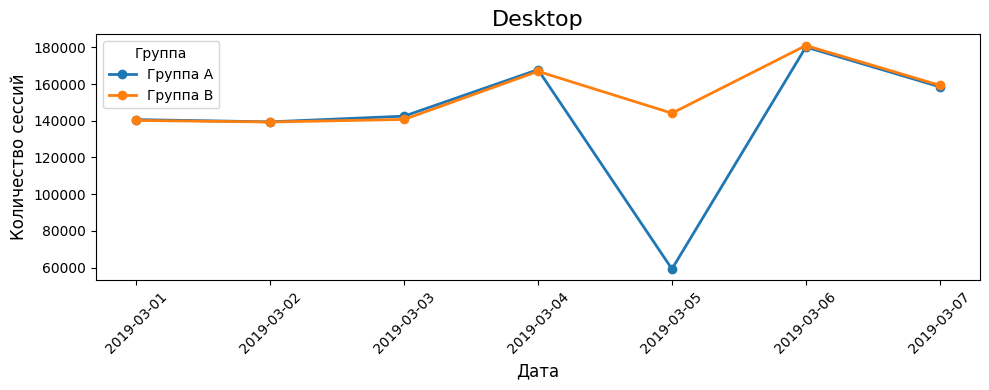

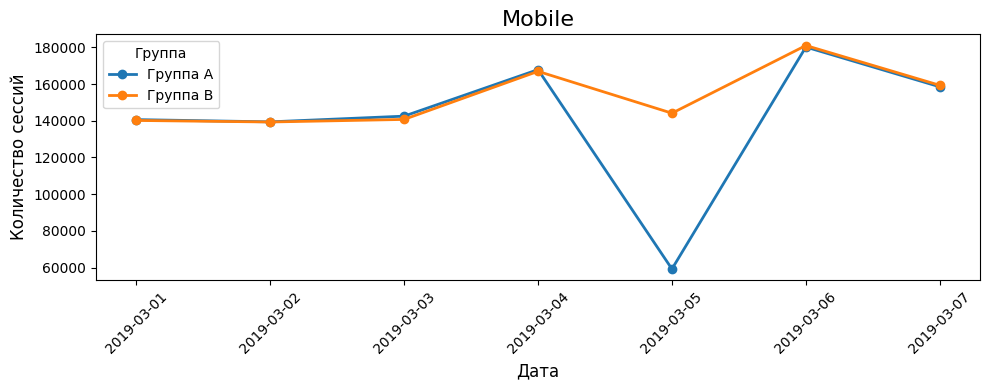

In [5]:
# Графисческая интерпретация
for name in platforms:
    daily_sessions = df.groupby(['date', 'group_name'])['sessions'].sum().reset_index()
    plt.figure(figsize=(10, 4))

    # Линейный график
    for group in daily_sessions['group_name'].unique():
        group_data = daily_sessions[daily_sessions['group_name'] == group]
        plt.plot(group_data['date'], group_data['sessions'], 
                marker='o', label=f'Группа {group}', linewidth=2)

    plt.title(f'{name}', fontsize=16)
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Количество сессий', fontsize=12)
    plt.legend(title='Группа')
    #plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [6]:
# удаление данных за 5 марта и пересчет пропорций наблюдений
# данные за 3 марта оставляем, так как расхождение меньше чем на 1%

# удаление
df_clean = df[df['date'] != '2019-03-05']


# проверка соблюдение пропорций выборок
# Н0: пропорции соблюдены, выборки представлены пропорционально 50/50    Н1: пропорции нарушены
for name in platforms:
    print(name)
    df_platform = df_clean[df_clean['platform'] == name]
    df_temp = df_platform.groupby('group_name')['sessions'].sum().to_dict()
    observed = [df_temp['A'], df_temp['B']]
    expected = [(df_temp['A'] + df_temp['B']) / 2, (df_temp['A'] + df_temp['B']) / 2]
    chi_pvalue = chisquare(observed, f_exp = expected).pvalue
    if chi_pvalue < alpha:
        print(f'''p-value = {chi_pvalue} < 0.05. Получили статистически значимое pvalue. Что говорит об отказе нулевой гипотезы в пользу альтернативной. 
    Необходимо произвести новый тест, либо искать некорректные данные и избавляться от них 
        ''')
    else:
        print(f'p-value = {round(chi_pvalue, 2)} > {alpha}, говорит, что нет оснований отвергать нулевую гипотезу и считать, что пропорции не соблюдены')

Desktop
p-value = 0.72 > 0.05, говорит, что нет оснований отвергать нулевую гипотезу и считать, что пропорции не соблюдены
Mobile
p-value = 0.24 > 0.05, говорит, что нет оснований отвергать нулевую гипотезу и считать, что пропорции не соблюдены


In [9]:
# Расчет количества необходимых наблюдений
alpha = 0.05
MDE = 0.05
beta = 0.2
power = 1-beta
# Ключевая метрика CTR_paid
dict_platform=dict()
for name in platforms:
     print(name)
     group_stats = (df_clean[df_clean['platform'] == name]
                    .groupby('group_name')
                    .agg({'sessions': 'sum',
                         'visible_pageviews':'sum',
                          'sponsord_clicks': 'sum'
                         })
     ).reset_index()
     group_stats['CTR_paid'] = group_stats['sponsord_clicks'] / group_stats['sessions']
     dict_platform[name] = group_stats

     # провка достаточности наблюдений
 
     CR_paid_A = group_stats.query("group_name == 'A'")['CTR_paid'].iloc[0]
     CR_paid_B_planned = CR_paid_A * (1 + MDE)
     effect_size = proportion_effectsize(prop2=CR_paid_B_planned, prop1=CR_paid_A)
     sample_size_per_group = tt_ind_solve_power(effect_size=effect_size,
                                             alpha=alpha,
                                             power=power,
                                             nobs1=None,        # Указываем None, чтобы функция рассчитала nobs1
                                             ratio=1.0,         # Соотношение групп 1:1
                                             alternative='two-sided' # Двусторонний тест 
     )
     print(f'''Необходимый размер выборки на одну группу: {np.ceil(sample_size_per_group):.0f} сессий.
           Группа А имеет {group_stats.query("group_name == 'A'")['sessions'].iloc[0]}.
           Группа B имеет {group_stats.query("group_name == 'B'")['sessions'].iloc[0]}.
           ''')

Desktop
Необходимый размер выборки на одну группу: 180334 сессий.
           Группа А имеет 348346.
           Группа B имеет 348050.
           
Mobile
Необходимый размер выборки на одну группу: 226493 сессий.
           Группа А имеет 580697.
           Группа B имеет 579420.
           


In [10]:
df_clean.to_csv('../data/processed/valid_data.csv', index = False)